# RSV-A truth benchmark (Fig2 panel A analogue)

The same figure as panel **A** of `simulated_hpv_runs_expanded/Fig2_expanded.ipynb`,
rebuilt on the bygul RSV-A experiments, which have a variant-level ground truth:

- **precision / recall / F1 per tool at each MAF threshold**. Each bar is the **median
  across experiments**, the whiskers are the **standard error**, and the median is
  printed above. A faint dot per experiment is drawn over the bars (`dot_alpha` /
  `dot_size` / `dot_color`, or `show_dots=False` to drop them); `kind='box'` /
  `kind='violin'` swap the bars for distribution shapes.
- the unit is one **experiment** (the HPV figure's unit was one dataset folder), so
  every dot is one bygul mixture scored against its own truth table.

`truth_comparison.tsv` holds one precision/recall/F1 per (experiment, caller, class),
scored at a single AF floor -- there is no MAF axis in it. So the per-experiment
TP/FP/FN are re-derived here from `af_accuracy.tsv`, which lists every variant with its
expected AF, its called AF and its TP/FP/FN status. At the 0.1% floor the recomputed
counts reproduce `truth_comparison.tsv` exactly; the check is a cell below.

Both tables come from `scripts/evaluate_vs_truth.py`, so the AF cutoff, edge exclusion
and iVar PASS filtering already match the bench run.

## Imports and constants

In [11]:
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.patches import Rectangle

MIN_AF = 0.001          # matches --min-af in scripts/run_experiments_bench.sh
EDGE_K = 21             # matches -k there; both already applied by evaluate_vs_truth.py
MAF_THRESHOLDS = [0.001, 0.005, 0.01, 0.015, 0.02, 0.05, 0.1]
TOOL_ORDER = ['bronko', 'lofreq', 'ivar']

RUN_ROOT = Path('/home/Users/rdd4/bronko-test/bronko_test/simulated_rsva_runs')
FIGURES_DIR = Path('/home/Users/rdd4/bronko-test/bronko_test/figures')

# same colours as Fig2 so the two benchmarks read as one figure set
_base_palette = sns.color_palette("colorblind", n_colors=4)
TOOL_PALETTE = dict(zip(TOOL_ORDER, [_base_palette[1], _base_palette[2], _base_palette[0]]))

## Loading

`af_accuracy.tsv` is one row per (experiment, caller, variant): every truth variant and
every call, tagged TP / FP / FN.

In [12]:
af_all = pd.read_csv(RUN_ROOT / 'af_accuracy.tsv', sep='\t')
summary = pd.read_csv(RUN_ROOT / 'truth_comparison.tsv', sep='\t')

# The quantity the x-axis thresholds on. A truth variant (TP or FN) is placed at the AF it
# was simulated at; a false positive has no truth AF, so it is placed at the AF the caller
# reported. This mirrors alt_maf in Fig2 -- truth MAF for a missed truth, the called
# allele's own frequency otherwise -- and keeps recall and precision on one shared axis.
af_all['maf'] = af_all['expected_af'].where(af_all['status'] != 'FP', af_all['called_af'])

print(f"{len(af_all):,} rows | {af_all['experiment'].nunique()} experiments "
      f"| callers: {sorted(af_all['caller'].unique())}")
print(af_all['status'].value_counts().to_string())
assert af_all['maf'].notna().all(), 'a row has neither an expected nor a called AF'
af_all.head()

16,588 rows | 95 experiments | callers: ['bronko', 'ivar', 'lofreq']
status
TP    11054
FP     3724
FN     1810


,experiment,caller,pos,ref,alt,expected_af,called_af,status,maf
0,1,bronko,330,G,A,0.4,0.386,TP,0.4
1,1,bronko,1263,T,A,0.4,0.385,TP,0.4
2,1,bronko,1318,G,A,0.4,0.368,TP,0.4
3,1,bronko,1761,T,A,0.4,0.392,TP,0.4
4,1,bronko,2873,A,G,0.4,0.388,TP,0.4


## Metrics

Precision / recall / F1 per tool at each MAF threshold, computed per experiment so each
experiment becomes one dot.

In [13]:
def compute_metrics(rows, maf_thresholds=MAF_THRESHOLDS, tool_order=TOOL_ORDER):
    """Precision / recall / F1 per tool at each MAF threshold, for one set of rows.

    A variant counts at a threshold when its `maf` clears it, so recall's denominator
    (truth variants above the threshold) and precision's (calls above the threshold) move
    together, exactly as in Fig2's compute_metrics().

    Degenerate cases, handled as in Fig2:

    - a tool that called NOTHING above the threshold has precision 0/0. It is scored 1:
      no calls means no false positives, so there is nothing to penalise on the precision
      axis. Its recall is 0, giving F1 = 0.
    - a tool that called something but got all of it wrong has precision 0 and recall 0,
      so F1's denominator is 0. It is scored 0 rather than left undefined.

    A threshold with no truth variant above it at all is skipped for that experiment:
    recall has no denominator there. Five of the 100 experiments have no truth variant
    left after the AF/edge filters and so drop out entirely.
    """
    out = []
    for maf in maf_thresholds:
        keep = rows[rows['maf'] >= maf]
        counts = (keep.groupby(['caller', 'status']).size().unstack(fill_value=0)
                  .reindex(index=tool_order, columns=['TP', 'FP', 'FN'], fill_value=0))
        # the truth set is shared by the three callers, so TP+FN is the same for each
        if int((counts['TP'] + counts['FN']).max()) == 0:
            continue
        for tool in tool_order:
            tp, fp, fn = (float(counts.loc[tool, c]) for c in ('TP', 'FP', 'FN'))
            # 0/0 -> 1.0: no calls means no false positives
            precision = tp / (tp + fp) if (tp + fp) else 1.0
            recall = tp / (tp + fn) if (tp + fn) else np.nan
            denom = precision + recall
            # denom == 0 only when the tool called something and got all of it wrong
            f1 = 2 * precision * recall / denom if denom > 0 else 0.0
            out.append(dict(tool=tool, MAF=maf, Precision=precision, Recall=recall, F1=f1,
                            TP=int(tp), FP=int(fp), FN=int(fn),
                            n_truth=int(tp + fn), n_called=int(tp + fp)))
    return pd.DataFrame(out)


def metrics_by_experiment(af, **kw):
    """One row per (experiment, tool, MAF) -- one dot per experiment in the figure."""
    return pd.concat(
        [compute_metrics(g, **kw).assign(unit=exp) for exp, g in af.groupby('experiment')],
        ignore_index=True)


experiment_metrics = metrics_by_experiment(af_all)

n_cells = len(experiment_metrics)
no_calls = int((experiment_metrics['n_called'] == 0).sum())
zero_f1 = int((experiment_metrics['F1'] == 0).sum())
print(f'{n_cells} (experiment, tool, MAF) cells from '
      f"{experiment_metrics['unit'].nunique()} experiments")
print(f'  {no_calls} called nothing above the threshold (precision scored 1, F1 0)')
print(f'  {zero_f1} have F1 = 0')
print('experiments contributing per threshold:',
      experiment_metrics.groupby('MAF')['unit'].nunique().to_dict())

1860 (experiment, tool, MAF) cells from 95 experiments
  3 called nothing above the threshold (precision scored 1, F1 0)
  3 have F1 = 0
experiments contributing per threshold: {0.001: 95, 0.005: 94, 0.01: 91, 0.015: 90, 0.02: 90, 0.05: 83, 0.1: 77}


### Check against `truth_comparison.tsv`

At the 0.1% floor -- the AF cutoff `evaluate_vs_truth.py` already applied -- the
recomputed TP/FP/FN must equal the `class == 'all'` rows of the precomputed table.

In [14]:
recomputed = (experiment_metrics[experiment_metrics['MAF'] == MIN_AF]
              .set_index(['unit', 'tool'])[['TP', 'FP', 'FN']])
precomputed = (summary[summary['class'] == 'all']
               .rename(columns={'experiment': 'unit', 'caller': 'tool'})
               .set_index(['unit', 'tool'])[['TP', 'FP', 'FN']])

joined = recomputed.join(precomputed, lsuffix='_new', rsuffix='_file', how='outer')
compared = joined.dropna()
disagree = compared[(compared['TP_new'] != compared['TP_file'])
                    | (compared['FP_new'] != compared['FP_file'])
                    | (compared['FN_new'] != compared['FN_file'])]
skipped = sorted(joined[joined['TP_new'].isna()].index.get_level_values('unit').unique())

print(f'{len(compared)} of {len(joined)} (experiment, caller) pairs compared, '
      f'{len(disagree)} disagree')
print(f'skipped -- no truth variant above {MIN_AF:.1%}: experiments {skipped}')
assert disagree.empty, 'recomputed counts do not match truth_comparison.tsv'

285 of 300 (experiment, caller) pairs compared, 0 disagree
skipped -- no truth variant above 0.1%: experiments [11, 12, 89, 93, 94]


## Variant counts

The raw counts behind the figure, pooled over experiments. `TP/(TP+FP)` and
`TP/(TP+FN)` here are pooled ratios, so they will not equal the bars, which are medians
over experiments -- the big mixtures (hundreds of truth variants) dominate a pooled
ratio.

In [15]:
def counts_pooled(metrics, tool_order=TOOL_ORDER):
    """TP / FP / FN summed over experiments, one row per (MAF, tool)."""
    agg = (metrics.groupby(['MAF', 'tool'], observed=False)
           .agg(n_experiments=('unit', 'nunique'), n_truth=('n_truth', 'sum'),
                TP=('TP', 'sum'), FP=('FP', 'sum'), FN=('FN', 'sum'))
           .reset_index())
    agg['Precision_pooled'] = agg['TP'] / (agg['TP'] + agg['FP']).replace(0, np.nan)
    agg['Recall_pooled'] = agg['TP'] / (agg['TP'] + agg['FN']).replace(0, np.nan)
    # 0/0 -> NaN for the same reason Precision_pooled/Recall_pooled do: nothing to
    # score at a threshold where nothing was called or nothing was true.
    f1_denom = (agg['Precision_pooled'] + agg['Recall_pooled']).replace(0, np.nan)
    agg['F1_pooled'] = 2 * agg['Precision_pooled'] * agg['Recall_pooled'] / f1_denom
    agg['tool'] = pd.Categorical(agg['tool'], categories=tool_order, ordered=True)
    return agg.sort_values(['MAF', 'tool']).reset_index(drop=True)


pooled = counts_pooled(experiment_metrics)
pooled.round(3)

,MAF,tool,n_experiments,n_truth,TP,FP,FN,Precision_pooled,Recall_pooled,F1_pooled
0,0.001,bronko,95,4288,3848,15,440,0.996,0.897,0.944
1,0.001,lofreq,95,4288,3755,82,533,0.979,0.876,0.924
2,0.001,ivar,95,4288,3451,3627,837,0.488,0.805,0.607
3,0.005,bronko,94,3963,3811,15,152,0.996,0.962,0.979
4,0.005,lofreq,94,3963,3747,82,216,0.979,0.945,0.962
5,0.005,ivar,94,3963,3433,1501,530,0.696,0.866,0.772
6,0.010,bronko,91,3584,3560,11,24,0.997,0.993,0.995
7,0.010,lofreq,91,3584,3548,14,36,0.996,0.990,0.993
8,0.010,ivar,91,3584,3324,99,260,0.971,0.927,0.949
9,0.015,bronko,90,3305,3304,3,1,0.999,1.000,0.999


### Truth variants remaining at each threshold

`n_truth` in `pooled` is already the same for every tool at a given threshold (the
truth set is shared), so pull out one tool's copy: the number of truth variants
that clear each MAF cutoff, pooled over all experiments. This is precision's other
denominator moving -- it shrinks fast because `expected_af` never exceeds 0.5 in
this experiment design (proportions_experiments.csv), while a caller's false
positives are not bounded the same way.

In [16]:
n_truth_by_threshold = (
    pooled[pooled['tool'] == TOOL_ORDER[0]]
    .set_index('MAF')[['n_experiments', 'n_truth']]
    .rename(columns={'n_truth': 'n_truth_variants'})
)
n_truth_by_threshold['n_truth_variants'] = n_truth_by_threshold['n_truth_variants'].astype(int)
n_truth_by_threshold['pct_of_floor'] = (
    100 * n_truth_by_threshold['n_truth_variants']
    / n_truth_by_threshold['n_truth_variants'].iloc[0]
).round(1)
display(n_truth_by_threshold)


,n_experiments,n_truth_variants,pct_of_floor
MAF,,,
0.001,95,4288,100.0
0.005,94,3963,92.4
0.010,91,3584,83.6
0.015,90,3305,77.1
0.020,90,3088,72.0
0.050,83,2357,55.0
0.100,77,1556,36.3


## The figure

In [17]:
def plot_precision_recall_f1(metrics, axes, maf_thresholds=MAF_THRESHOLDS,
                             tool_order=TOOL_ORDER, kind='bar', show_dots=True,
                             show_values=True, dot_size=2.5, dot_alpha=0.25,
                             dot_color='0.15', values_above='error', value_fmt='{:.2f}',
                             legend=False, ylim=(0, 1.18), bold=False,
                             titles=('iSNV Precision', 'iSNV Recall', 'iSNV F1 Score')):
    """Precision / recall / F1 per tool at each MAF threshold.

    `metrics` is tidy output from metrics_by_experiment, with columns unit, tool, MAF and
    the three metric columns. Same plotting code as Fig2_expanded, one unit = one
    experiment.

    kind='bar'    bar at the MEDIAN across units, whiskers = standard error
                  (std/sqrt(n), ddof=1 -- seaborn's errorbar='se'), value printed above.
                  Note the pairing is the one used in Fig2, not the textbook one: the
                  standard error describes the spread of the MEAN, so on a skewed
                  metric the whiskers are not centred on the bar they sit on.
    kind='box'    box of the distribution (no error bars, no value labels)
    kind='violin' violin of the distribution

    show_dots overlays one dot per unit, faint by default (dot_alpha / dot_size /
    dot_color) so the bars stay the thing you read first.

    values_above='error' puts each value just above its error bar, so the number stays
    attached to its own bar; ='dots' clears the highest dot instead.

    Font sizes are left to rcParams so the style block in the figure cell governs them;
    only bold is set here, which no rcParam covers.
    """
    metrics = metrics[metrics['MAF'].isin(maf_thresholds)].copy()
    metrics['MAF'] = pd.Categorical(metrics['MAF'], categories=maf_thresholds, ordered=True)

    for ax, metric, title in zip(axes, ('Precision', 'Recall', 'F1'), titles):
        data = metrics.dropna(subset=[metric])

        if kind == 'bar':
            sns.barplot(data=data, x='MAF', y=metric, hue='tool', hue_order=tool_order,
                        palette=TOOL_PALETTE, ax=ax, estimator='median', errorbar='se',
                        capsize=0.12, err_kws={'linewidth': 0.9}, legend=False)
        elif kind == 'violin':
            sns.violinplot(data=data, x='MAF', y=metric, hue='tool', hue_order=tool_order,
                           palette=TOOL_PALETTE, ax=ax, width=0.7, linewidth=0.9,
                           legend=False)
        else:
            sns.boxplot(data=data, x='MAF', y=metric, hue='tool', hue_order=tool_order,
                        palette=TOOL_PALETTE, ax=ax, showfliers=False, width=0.7,
                        linewidth=0.9, fliersize=0, legend=False)

        if show_dots:
            # one dot per experiment, kept faint so it reads as texture over the bar
            sns.stripplot(data=data, x='MAF', y=metric, hue='tool', hue_order=tool_order,
                          dodge=True, jitter=0.12, size=dot_size, alpha=dot_alpha,
                          linewidth=0, palette={t: dot_color for t in tool_order},
                          ax=ax, legend=False)

        if kind == 'bar' and show_values:
            _label_bars(ax, data, metric, maf_thresholds, tool_order, value_fmt=value_fmt,
                        over_dots=(show_dots and values_above == 'dots'))
        if bold:
            ax.set_title(title, fontweight='bold')
            ax.set_ylabel(metric, fontweight='bold')
            ax.set_xlabel('MAF Threshold', fontweight='bold')
        else:
            ax.set_title(title)
            ax.set_ylabel(metric)
            ax.set_xlabel('MAF Threshold')
        ax.set_ylim(*ylim)

        ax.set_xticks(range(len(maf_thresholds)))
        ax.set_xticklabels([f"{m*100:g}%" for m in maf_thresholds])
        if legend and ax is axes[0]:
            ax.legend(*tool_handles(tool_order), frameon=False, loc='lower left')
    return metrics


def _label_bars(ax, data, metric, maf_thresholds, tool_order, value_fmt='{:.2f}',
                over_dots=True):
    """Print each bar's median above it, clear of its error bar (and of the dots).

    Placed per bar rather than with ax.bar_label(padding=...), which takes one padding
    for every bar and so collides with the taller error bars.
    """
    stats = (data.groupby(['MAF', 'tool'], observed=False)[metric]
             .agg(median='median',
                  sem=lambda s: s.std(ddof=1) / np.sqrt(len(s)) if len(s) > 1 else 0.0,
                  top='max'))
    # containers come back in hue_order, bars within one in x-category order
    for container, tool in zip(ax.containers, tool_order):
        for bar, maf in zip(container, maf_thresholds):
            if (maf, tool) not in stats.index:
                continue
            row = stats.loc[(maf, tool)]
            if pd.isna(row['median']):
                continue
            y = row['median'] + (0.0 if pd.isna(row['sem']) else row['sem'])
            if over_dots:
                y = max(y, row['top'])
            ax.annotate(value_fmt.format(row['median']),
                        xy=(bar.get_x() + bar.get_width() / 2, y),
                        xytext=(0, 2), textcoords='offset points',
                        ha='center', va='bottom', fontweight='bold', zorder=6,
                        fontsize=plt.rcParams['font.size'] * 0.85)


def tool_handles(tool_order=TOOL_ORDER):
    """(handles, labels) for a tool colour key, matching the bars."""
    return ([Rectangle((0, 0), 1, 1, facecolor=TOOL_PALETTE[t], edgecolor='k', lw=0.5)
             for t in tool_order], ['bronko', 'LoFreq', 'iVar'])

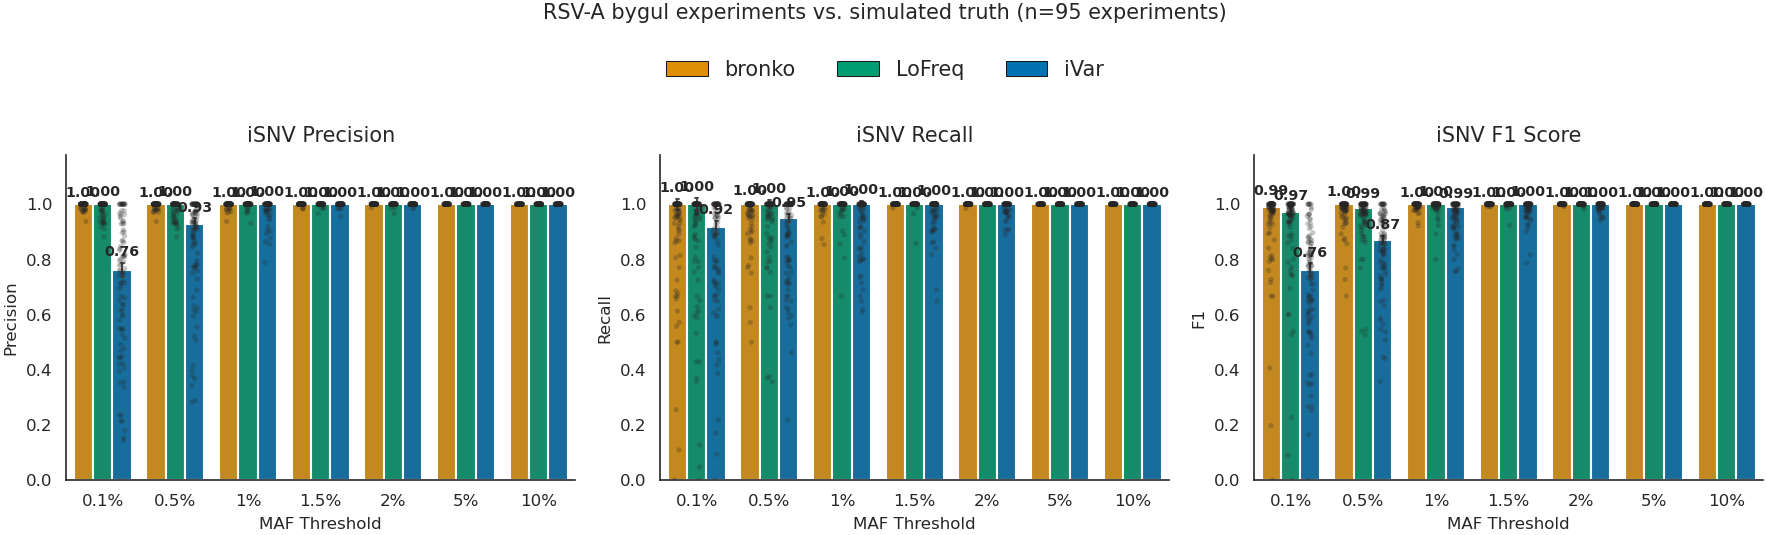

In [18]:
sns.set_theme(style="white")

# style block first: axes.spines.* and the figure-level keys are read when the figure and
# its axes are created, so setting them after plt.subplots() leaves the spines untouched
mpl.rcParams.update({
    # Fonts
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],

    # Editable fonts in PDF/PS
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",

    # Font sizes (8-10 pt)
    "font.size": 8,
    "axes.labelsize": 8,
    "axes.titlesize": 10,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,

    # Axes
    "axes.linewidth": 0.8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.major.size": 3,
    "ytick.major.size": 3,

    # Lines
    "lines.linewidth": 1.5,
    "lines.markersize": 5,

    # Save figures
    "savefig.dpi": 600,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,

    # Figure defaults
    "figure.dpi": 150,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
})

fig, axes = plt.subplots(1, 3, figsize=(12, 3.2))

# bar = median across experiments, whiskers = standard error, value on top, plus a faint
# dot per experiment. dot_alpha / dot_size / dot_color tune how faint.
plot_precision_recall_f1(experiment_metrics, axes, kind='bar', show_dots=True,
                         dot_size=2.5, dot_alpha=0.25)

n_exp = experiment_metrics['unit'].nunique()
fig.legend(*tool_handles(), loc='upper center', ncol=3, frameon=False, fontsize=10,
           bbox_to_anchor=(0.5, 1.06))
fig.suptitle(f'RSV-A bygul experiments vs. simulated truth (n={n_exp} experiments)',
             y=1.14, fontsize=10)

fig.tight_layout()
for ext in ('png', 'pdf', 'svg'):
    fig.savefig(FIGURES_DIR / f'FigRSVA_truth_panelA.{ext}', bbox_inches='tight', dpi=600,
                facecolor='white')
plt.show()

### Distribution instead of medians

The same units as boxes, in case the spread across experiments matters more than the
median. `kind='violin'` also works.

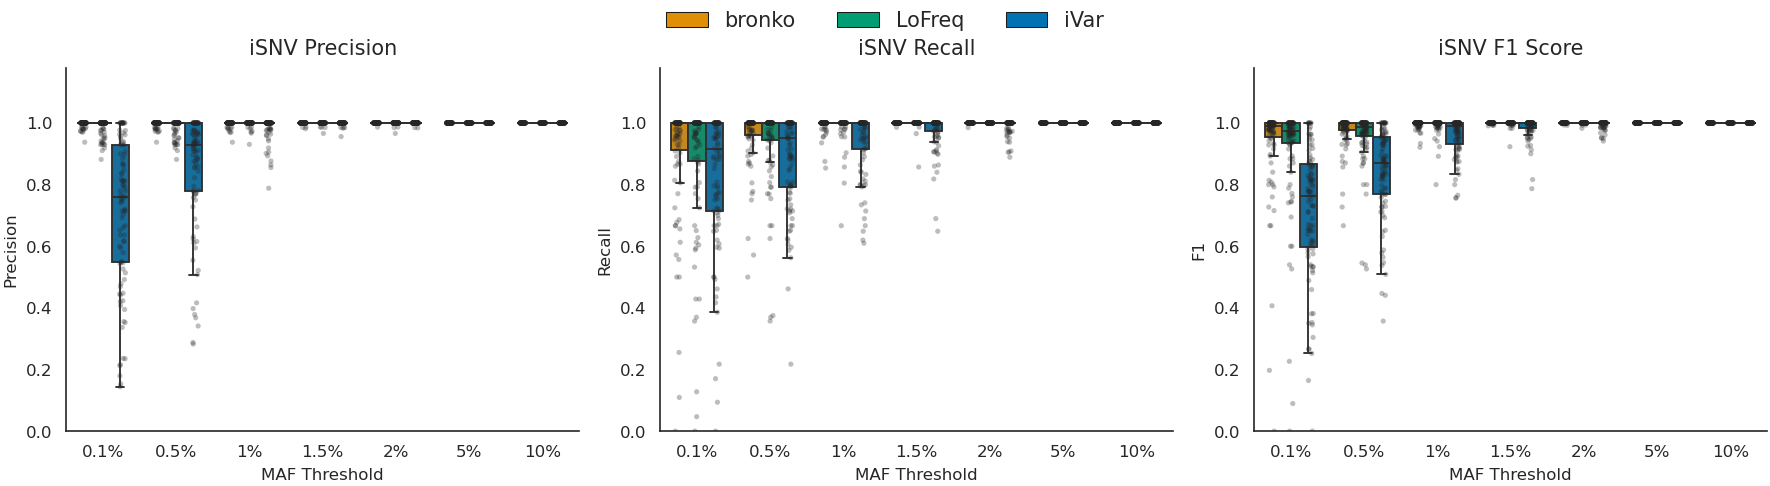

In [19]:
fig_box, axes_box = plt.subplots(1, 3, figsize=(12, 3.2))
plot_precision_recall_f1(experiment_metrics, axes_box, kind='box', show_dots=True,
                         dot_size=2.5, dot_alpha=0.3)
fig_box.legend(*tool_handles(), loc='upper center', ncol=3, frameon=False, fontsize=10,
               bbox_to_anchor=(0.5, 1.06))
fig_box.tight_layout()
for ext in ('png', 'pdf', 'svg'):
    fig_box.savefig(FIGURES_DIR / f'FigRSVA_truth_panelA_box.{ext}', bbox_inches='tight',
                    dpi=600, facecolor='white')
plt.show()

### Pooled (merged) precision / recall / F1

One value per tool per threshold: every experiment's TP/FP/FN are summed into a
single confusion matrix first (`counts_pooled` above), then scored once -- no
median, no error bars, no per-experiment dots. This is the pooled-ratio caveat
from the "Variant counts" section turned into the same three-panel figure as
the median-of-experiments version, so the two are easy to compare directly. A
few large mixtures dominate this version; every experiment counts equally in
the median-of-experiments one.

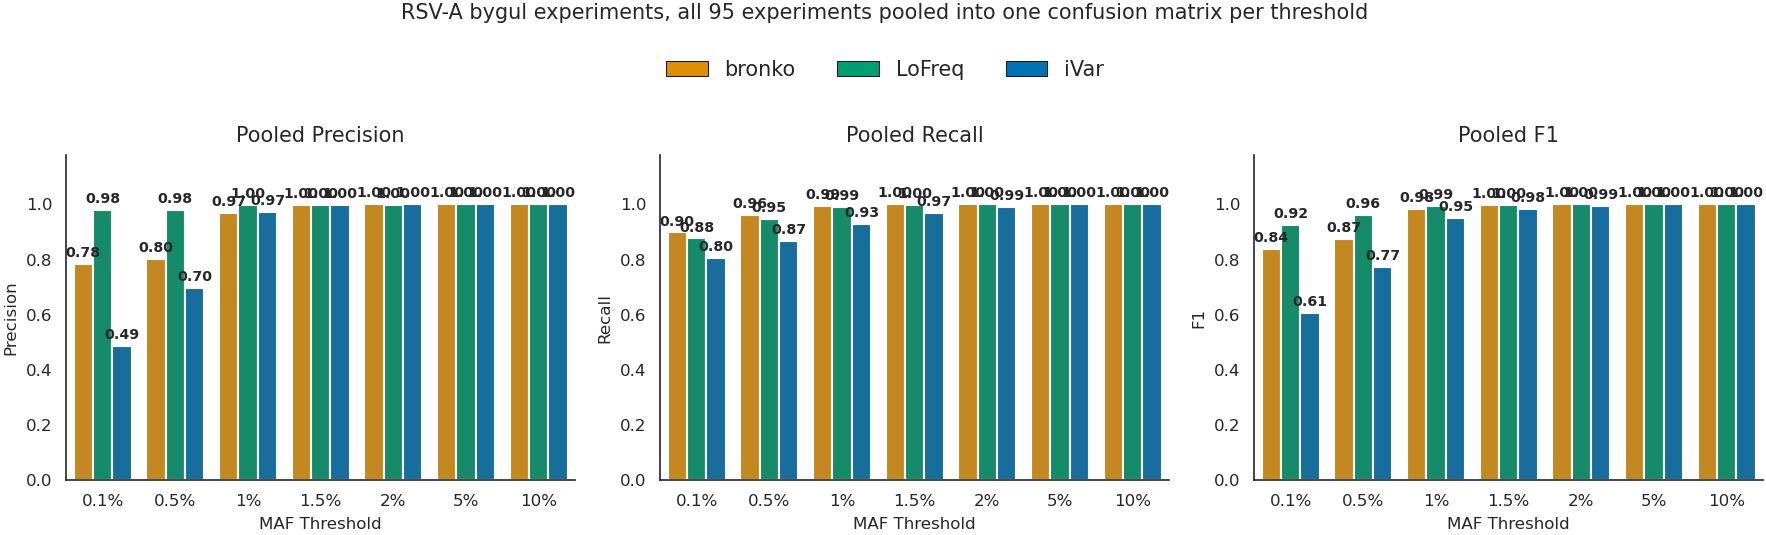

In [10]:
def plot_pooled_precision_recall_f1(pooled, axes, maf_thresholds=MAF_THRESHOLDS,
                                     tool_order=TOOL_ORDER, value_fmt='{:.2f}',
                                     legend=False, ylim=(0, 1.18),
                                     titles=('Pooled Precision', 'Pooled Recall',
                                             'Pooled F1')):
    """Precision / recall / F1 from one confusion matrix per (tool, MAF threshold),
    pooled across every experiment -- one bar, not a median of many.

    Companion to plot_precision_recall_f1: that one draws a bar at the median across
    experiments with SE whiskers and a dot per experiment; this draws the single
    value you get from summing TP/FP/FN over all experiments first. `pooled` is the
    output of counts_pooled(), with columns MAF, tool, Precision_pooled,
    Recall_pooled, F1_pooled.
    """
    data = pooled[pooled['MAF'].isin(maf_thresholds)].copy()
    data['MAF'] = pd.Categorical(data['MAF'], categories=maf_thresholds, ordered=True)

    metric_cols = [('Precision', 'Precision_pooled'), ('Recall', 'Recall_pooled'),
                   ('F1', 'F1_pooled')]
    for ax, (metric, col), title in zip(axes, metric_cols, titles):
        sns.barplot(data=data, x='MAF', y=col, hue='tool', hue_order=tool_order,
                    palette=TOOL_PALETTE, ax=ax, legend=False)

        # one bar per (MAF, tool) already -- just print its own value above it
        for container, tool in zip(ax.containers, tool_order):
            for bar, maf in zip(container, maf_thresholds):
                row = data.loc[(data['MAF'] == maf) & (data['tool'] == tool), col]
                if row.empty or pd.isna(row.iloc[0]):
                    continue
                ax.annotate(value_fmt.format(row.iloc[0]),
                            xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                            xytext=(0, 2), textcoords='offset points',
                            ha='center', va='bottom', fontweight='bold', zorder=6,
                            fontsize=plt.rcParams['font.size'] * 0.85)

        ax.set_title(title)
        ax.set_ylabel(metric)
        ax.set_xlabel('MAF Threshold')
        ax.set_ylim(*ylim)
        ax.set_xticks(range(len(maf_thresholds)))
        ax.set_xticklabels([f"{m*100:g}%" for m in maf_thresholds])
        if legend and ax is axes[0]:
            ax.legend(*tool_handles(tool_order), frameon=False, loc='lower left')
    return data


fig_pooled, axes_pooled = plt.subplots(1, 3, figsize=(12, 3.2))
plot_pooled_precision_recall_f1(pooled, axes_pooled)

fig_pooled.legend(*tool_handles(), loc='upper center', ncol=3, frameon=False,
                  fontsize=10, bbox_to_anchor=(0.5, 1.06))
fig_pooled.suptitle(
    f'RSV-A bygul experiments, all {n_exp} experiments pooled into one confusion '
    'matrix per threshold', y=1.14, fontsize=10)

fig_pooled.tight_layout()
for ext in ('png', 'pdf', 'svg'):
    fig_pooled.savefig(FIGURES_DIR / f'FigRSVA_truth_panelA_pooled.{ext}',
                       bbox_inches='tight', dpi=600, facecolor='white')
plt.show()


## The numbers behind the bars

In [21]:
medians = (experiment_metrics
           .groupby(['MAF', 'tool'], observed=False)[['Precision', 'Recall', 'F1']]
           .median().round(3).unstack('tool'))
display(medians)

experiment_metrics.to_csv(RUN_ROOT / 'truth_experiment_metrics.csv', index=False)
print(f"wrote {RUN_ROOT / 'truth_experiment_metrics.csv'}")

Precision               Recall                   F1              
tool     bronko   ivar lofreq bronko   ivar lofreq bronko   ivar lofreq
MAF                                                                    
0.001     0.947  0.761    1.0  0.983  0.917    1.0  0.918  0.763  0.973
0.005     0.945  0.929    1.0  1.000  0.950    1.0  0.940  0.871  0.986
0.010     0.953  1.000    1.0  1.000  1.000    1.0  0.968  0.989  1.000
0.015     1.000  1.000    1.0  1.000  1.000    1.0  1.000  1.000  1.000
0.020     1.000  1.000    1.0  1.000  1.000    1.0  1.000  1.000  1.000
0.050     1.000  1.000    1.0  1.000  1.000    1.0  1.000  1.000  1.000
0.100     1.000  1.000    1.0  1.000  1.000    1.0  1.000  1.000  1.000

wrote /home/Users/rdd4/bronko-test/bronko_test/simulated_rsva_runs/truth_experiment_metrics.csv
